### Import relevant libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from lstm_model import LSTMModel

### Load dataset

In [2]:
X_train, y_train, X_val, y_val, X_test, y_test = np.load('../datasets/video_frame_features_supervised_data.npz', allow_pickle=True).values()

In [3]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((80000, 12, 512),
 (80000,),
 (10000, 12, 512),
 (10000,),
 (10000, 12, 512),
 (10000,))

In [4]:
SEED = 42
torch.manual_seed(SEED)

# Create data loaders
batch_size = 128
train_loader = DataLoader(list(zip(X_train, y_train)), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(list(zip(X_val, y_val)), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(list(zip(X_test, y_test)), batch_size=batch_size, shuffle=False)

In [5]:
# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Train model using LSTM based on PyTorch

In [6]:
import copy

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_val_loss = float('inf')
        self.early_stop = False
        self.counter = 0
        self.best_model_state = None
        self.best_optimizer_state = None
        self.best_epoch = None

    def __call__(self, val_loss, model, optimizer, epoch):
        if val_loss > self.best_val_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_val_loss = val_loss
            self.best_model_state = copy.deepcopy(model.state_dict())
            self.best_optimizer_state = copy.deepcopy(optimizer.state_dict())
            self.best_epoch = epoch
            self.counter = 0

    def restore_best_model(self, model, optimizer):
        print('Restoring best model...')
        model.load_state_dict(self.best_model_state)
        optimizer.load_state_dict(self.best_optimizer_state) 

In [7]:
# define hyperparameters
input_size = X_train.shape[2] # number of features
hidden_size = 64
num_layers = 3
output_size = 1 # binary classification with sigmoid activation
dropout = 0.3
lr = 0.0001

In [9]:
# initialize model
model = LSTMModel(input_size, hidden_size, num_layers, dropout, output_size, bidirectional=False).to(device)
model

LSTMModel(
  (lstm): LSTM(512, 64, num_layers=3, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

In [10]:
# Define loss function and optimizer
n_patience = 10
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
early_stopping = EarlyStopping(patience=20, min_delta=0.001)

# Schedule learning rate
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=n_patience, verbose=True)

In [13]:
# train model
num_epochs = 100
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for X_train_batch, y_train_batch in train_loader:
        X_train_batch, y_train_batch = X_train_batch.to(device).float(), y_train_batch.to(device).float()
        
        # forward pass
        outputs = model(X_train_batch)
        loss = criterion(outputs, y_train_batch)
        
        # backward and optimize
        optimizer.zero_grad()
        loss.backward()
        # Apply gradient clipping to prevent exploding gradient in LSTMs
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0
    val_acc = 0
    with torch.no_grad():
        for X_valid_batch, y_valid_batch in val_loader:
            X_valid_batch, y_valid_batch = X_valid_batch.to(device).float(), y_valid_batch.to(device).float()
            outputs = model(X_valid_batch)
            v_loss = criterion(outputs, y_valid_batch)
            val_loss += v_loss.item()
            probs = torch.sigmoid(outputs)
            val_acc += (probs.round() == y_valid_batch).float().mean()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    val_acc /= len(val_loader)
    
    scheduler.step(val_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Train_loss: {train_loss:.6f}, Val_loss: {val_loss:.6f}, Val_acc: {val_acc:.6f}')
    early_stopping(val_loss, model, optimizer, epoch+1)
    if early_stopping.early_stop:
        print(f'Early stopping at epoch {epoch+1}')
        break

# load best model
early_stopping.restore_best_model(model, optimizer)
print(f'Best epoch: {early_stopping.best_epoch} with val_ loss: {early_stopping.best_val_loss:.6f}')

Epoch [1/100], Train_loss: 0.021110, Val_loss: 0.014230, Val_acc: 0.996934
Epoch [2/100], Train_loss: 0.013106, Val_loss: 0.010913, Val_acc: 0.997033
Epoch [3/100], Train_loss: 0.009431, Val_loss: 0.008814, Val_acc: 0.997528
Epoch [4/100], Train_loss: 0.006636, Val_loss: 0.010921, Val_acc: 0.997429
Epoch [5/100], Train_loss: 0.005023, Val_loss: 0.015076, Val_acc: 0.996835
Epoch [6/100], Train_loss: 0.003839, Val_loss: 0.013411, Val_acc: 0.993968
Epoch [7/100], Train_loss: 0.002974, Val_loss: 0.013628, Val_acc: 0.997132
Epoch [8/100], Train_loss: 0.002743, Val_loss: 0.014284, Val_acc: 0.995154
Epoch [9/100], Train_loss: 0.001736, Val_loss: 0.028372, Val_acc: 0.992089
Epoch [10/100], Train_loss: 0.001886, Val_loss: 0.024046, Val_acc: 0.993473
Epoch [11/100], Train_loss: 0.001531, Val_loss: 0.014747, Val_acc: 0.996539
Epoch [12/100], Train_loss: 0.001538, Val_loss: 0.021710, Val_acc: 0.994363
Epoch [13/100], Train_loss: 0.001105, Val_loss: 0.017073, Val_acc: 0.996242
Epoch [14/100], Train

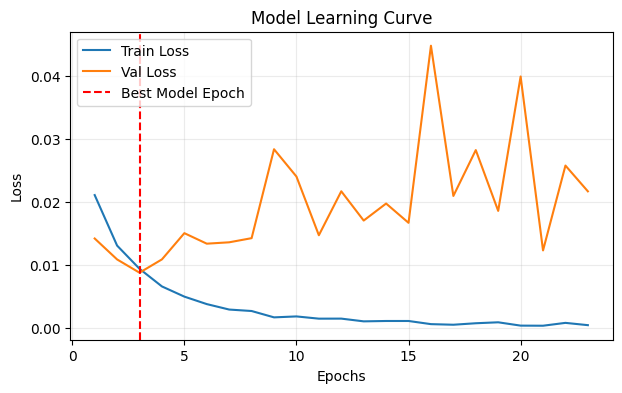

In [14]:
# Plot model learning curve
plt.figure(figsize=(7, 4))
plt.title('Model Learning Curve')
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, label='Val Loss')
plt.axvline(x=early_stopping.best_epoch, color='r', linestyle='--', label=f'Best Model Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [16]:
# evaluate model
y_pred = []
y_true = []
y_scores = []

model.eval()
with torch.no_grad():
    for X_test_batch, y_test_batch in test_loader:
        X_test_batch, y_test_batch = X_test_batch.to(device).float(), y_test_batch.to(device)
        y_true.append(y_test_batch.cpu().numpy())
        logits = model(X_test_batch)
        probs = torch.sigmoid(logits)
        y_scores.append(probs.cpu().numpy()) # save probability scores
        preds = (probs > 0.5).cpu().numpy().astype(int)
        y_pred.append(preds)

In [17]:
y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)
y_scores = np.concatenate(y_scores)

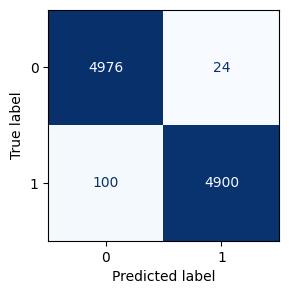

----------------- Classification Report -----------------

              precision    recall  f1-score   support

           0     0.9803    0.9952    0.9877      5000
           1     0.9951    0.9800    0.9875      5000

    accuracy                         0.9876     10000
   macro avg     0.9877    0.9876    0.9876     10000
weighted avg     0.9877    0.9876    0.9876     10000



In [18]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred, cmap='Blues', colorbar=None)
fig = disp.figure_
fig.set_figwidth(3)
fig.set_figheight(3) 
plt.grid(False)
plt.show()

# print classification report
print("----------------- Classification Report -----------------\n")
print(classification_report(y_true,y_pred, digits=4))

In [19]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC for the positive class with softmax
# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)
roc_auc

0.99935324

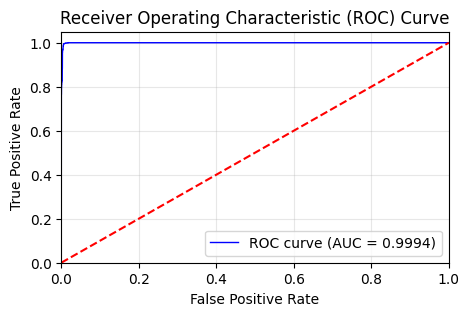

In [20]:
# Plot ROC curve
plt.figure(figsize=(5, 3))
plt.plot(fpr, tpr, color='blue', lw=1, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Define model version
version = 'v1' 

In [ ]:
# Saving model

torch.save(model, f'../models/lstm_model_{version}.pt')

# Save training history
with open(f'../models/lstm_train_histories.txt', 'a') as f:
    text = f"version={version}, best_epochs={early_stopping.best_epoch}, auc={roc_auc:.4f}\n"
    text += f"dropout={dropout}, lr={lr}\n"
    text += f"{classification_report(y_true,y_pred, digits=4)}\n"
    text += f"{'-'*75}\n"
    f.write(text)